In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
import pydicom

In [55]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
import ct

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
csv_path = './rsna_ich_subset_1149_complete.csv'
rsna_dir = '/media/M2SSD/gen_models_data/stage_2_train'

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(39710, 14)


,scan_id,slice_id,split,scan_label,slice_order,total_slices,z_position,instance_number,label_any,label_epidural,label_intraparenchymal,label_intraventricular,label_subarachnoid,label_subdural
0,ID_00047d6503,ID_ed600c22e,test,0,1,40,183.222504,NaN,0,0,0,0,0,0
1,ID_00047d6503,ID_087208a31,test,0,2,40,178.222504,NaN,0,0,0,0,0,0
2,ID_00047d6503,ID_506d20418,test,0,3,40,173.222504,NaN,0,0,0,0,0,0
3,ID_00047d6503,ID_3e299291c,test,0,4,40,168.222504,NaN,0,0,0,0,0,0
4,ID_00047d6503,ID_39ba043b0,test,0,5,40,163.222504,NaN,0,0,0,0,0,0


In [57]:
# scan_id = StudyInstanceUID, slice_id = SOPInstanceUID (DICOM filename)
print(f"Scans: {df['scan_id'].nunique()}")
print(f"Slices: {len(df)}")
print()
print(df.groupby(['split', 'scan_label'])['scan_id'].nunique().unstack(fill_value=0))

Scans: 1149
Slices: 39710

scan_label    0    1
split               
test         78   72
train       588  411


In [58]:
def load_dicom_slice(slice_id, base_path, normalize=True):
    dcm = pydicom.dcmread(f"{base_path}/{slice_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = img * float(getattr(dcm, 'RescaleSlope', 1)) + float(getattr(dcm, 'RescaleIntercept', 0))
    img = ct.strip_skull(img)  # clip to [-100, 300] HU
    if normalize:
        img = (img - (-100)) / (300 - (-100))
    return img

def load_scan(scan_id, df, base_path):
    slice_info = df[df['scan_id'] == scan_id].sort_values('slice_order')
    images = [load_dicom_slice(row['slice_id'], base_path) for _, row in slice_info.iterrows()]
    return images, slice_info

In [59]:
# Load a positive scan
positive_scans = df[df['scan_label'] == 1].groupby('scan_id')['label_any'].sum().sort_values(ascending=False)
scan_id = positive_scans.index[10]

images, slice_info = load_scan(scan_id, df, rsna_dir)
print(f"{scan_id}: {len(images)} slices, {slice_info['label_any'].sum()} positive")

ID_079b103f05: 38 slices, 26 positive


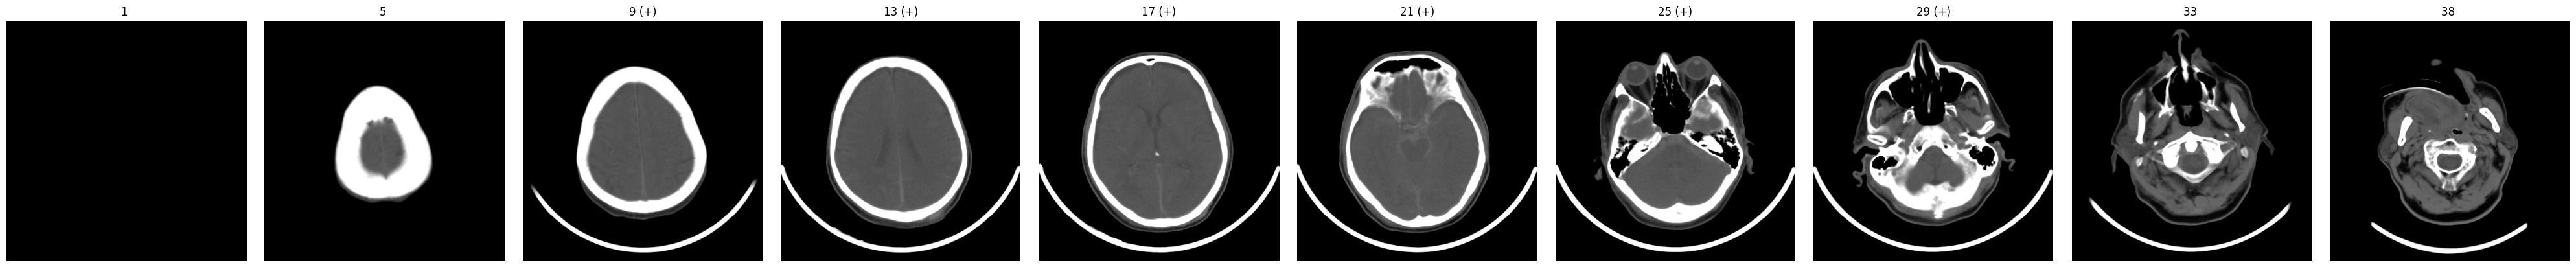

In [60]:
linspace = np.linspace(0, len(images) - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols, 4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(images[j], cmap='gray', vmin=0, vmax=1)
    label = slice_info.iloc[j]['label_any']
    axs[i].set_title(f"{j+1} {'(+)' if label else ''}")
    axs[i].set_axis_off()

fig.tight_layout()
plt.show()

In [65]:
df.head()

,scan_id,slice_id,split,scan_label,slice_order,total_slices,z_position,instance_number,label_any,label_epidural,label_intraparenchymal,label_intraventricular,label_subarachnoid,label_subdural
0,ID_00047d6503,ID_ed600c22e,test,0,1,40,183.222504,NaN,0,0,0,0,0,0
1,ID_00047d6503,ID_087208a31,test,0,2,40,178.222504,NaN,0,0,0,0,0,0
2,ID_00047d6503,ID_506d20418,test,0,3,40,173.222504,NaN,0,0,0,0,0,0
3,ID_00047d6503,ID_3e299291c,test,0,4,40,168.222504,NaN,0,0,0,0,0,0
4,ID_00047d6503,ID_39ba043b0,test,0,5,40,163.222504,NaN,0,0,0,0,0,0


In [61]:
# Verify DICOM metadata matches CSV IDs
sample_slice = df.iloc[0]
dcm = pydicom.dcmread(f"{rsna_dir}/{sample_slice['slice_id']}.dcm")

print(f"slice_id: {sample_slice['slice_id']}")
print(f"SOPInstanceUID: {dcm.SOPInstanceUID}")
print(f"match: {sample_slice['slice_id'] == dcm.SOPInstanceUID}")
print()
print(f"scan_id: {sample_slice['scan_id']}")
print(f"StudyInstanceUID: {dcm.StudyInstanceUID}")
print(f"match: {sample_slice['scan_id'] == dcm.StudyInstanceUID}")

slice_id: ID_ed600c22e
SOPInstanceUID: ID_ed600c22e
match: True

scan_id: ID_00047d6503
StudyInstanceUID: ID_00047d6503
match: True


/home/denny-loevlie/.local/lib/python3.10/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_ed600c22e'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/home/denny-loevlie/.local/lib/python3.10/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_00047d6503'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


In [62]:
# Compare with HuggingFace torchmil/RSNA_ICH_MIL dataset
from huggingface_hub import hf_hub_download

hf_path = hf_hub_download(repo_id="torchmil/RSNA_ICH_MIL", filename="dataset/splits.csv", repo_type="dataset")
hf_df = pd.read_csv(hf_path)
print(f"HuggingFace columns: {list(hf_df.columns)}")
print(f"HuggingFace rows: {len(hf_df)}")
hf_df.head()

HuggingFace columns: ['bag_name', 'split']
HuggingFace rows: 39750


,bag_name,split
0,ID_00047d6503,train
1,ID_00047d6503,train
2,ID_00047d6503,train
3,ID_00047d6503,train
4,ID_00047d6503,train


In [63]:
# HuggingFace bag_name = scan_id (StudyInstanceUID)
# HuggingFace does not include slice IDs - must get from DICOM files
hf_scans = set(hf_df['bag_name'].unique())
csv_scans = set(df['scan_id'].unique())

print(f"HuggingFace scans: {len(hf_scans)}")
print(f"CSV scans: {len(csv_scans)}")
print(f"Overlap: {len(hf_scans & csv_scans)}")

HuggingFace scans: 1149
CSV scans: 1149
Overlap: 1149


In [ ]:
# Compare with HuggingFace torchmil/RSNA_ICH_MIL dataset
from huggingface_hub import hf_hub_download

hf_path = hf_hub_download(repo_id="torchmil/RSNA_ICH_MIL", filename="dataset/splits.csv", repo_type="dataset")
hf_df = pd.read_csv(hf_path)
print(f"HuggingFace columns: {list(hf_df.columns)}")
print(f"HuggingFace rows: {len(hf_df)}")
hf_df.head()

# HuggingFace has a data leak: one scan in both train and test
hf_train = set(hf_df[hf_df['split'] == 'train']['bag_name'].unique())
hf_test = set(hf_df[hf_df['split'] == 'test']['bag_name'].unique())
overlap = hf_train & hf_test

print(f"Scans in both train and test: {overlap}")
print(f"CSV fixes this by putting {list(overlap)[0]} in test only")

Scans in both train and test: {'ID_00047d6503'}
CSV fixes this by putting ID_00047d6503 in test only


In [ ]:
# Generate SLURM commands for parallel preprocessing of full RSNA dataset
# Total scans: 21,744

labels_csv = '/cluster/tufts/hugheslab/datasets/RSNA/labels.csv'
numpy_dir = '/cluster/tufts/hugheslab/datasets/RSNA_numpy'

total_scans = 21744
num_jobs = 10

starts = np.linspace(0, total_scans, num=num_jobs+1).astype(int)[:-1]
stops = np.linspace(0, total_scans, num=num_jobs+1).astype(int)[1:]

print("SLURM commands for parallel preprocessing:")
print()
for start, stop in zip(starts, stops):
    print(f'    "python ../src/preprocess_rsna_full.py --labels_csv=\'{labels_csv}\' --numpy_dir=\'{numpy_dir}\' --start={start} --stop={stop}"')

In [ ]:
# Generate SLURM commands for encoding full RSNA dataset

labels_csv = '/cluster/tufts/hugheslab/datasets/RSNA/labels.csv'
numpy_dir = '/cluster/tufts/hugheslab/datasets/RSNA_numpy'
encoded_dir = '/cluster/tufts/hugheslab/dloevl01/encoded_RSNA'

encoder = 'ViT-B/16'
encoder_name = 'ViT_B_16'
seeds = [1001, 2001, 3001]

print("SLURM commands for encoding:")
print()
for seed in seeds:
    print(f'    "python ../src/encode_rsna_full.py --encoded_dir=\'{encoded_dir}/{encoder_name}/seed={seed}\' --encoder=\'{encoder}\' --labels_csv=\'{labels_csv}\' --numpy_dir=\'{numpy_dir}\' --seed={seed}"')

In [ ]:
# Generate SLURM commands for hyperparameter search on full RSNA dataset
import itertools

dataset_dir = '/cluster/tufts/hugheslab/dloevl01/encoded_RSNA/ViT_B_16'
experiments_dir = '/cluster/tufts/hugheslab/dloevl01/pooling/experiments/RSNA/embedding_level=True'

alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
lrs = [0.1, 0.01, 0.001, 0.0001]
criterions = ['L1']
seeds = [1001, 2001, 3001]
poolings = ['Mean', 'ABMIL']

batch_size = 64
epochs = 1000
weight_decay = 0.0

# Map display names to oasis-3.py pooling arg values
pooling_arg_map = {'Mean': 'mean', 'ABMIL': 'attention'}

experiments = []

# Embedding-level experiments only
for alpha, lr, pooling, criterion, seed in itertools.product(alphas, lrs, poolings, criterions, seeds):
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    pooling_arg = pooling_arg_map[pooling]
    cmd = (
        f"python ../src/oasis-3.py "
        f"--alpha={alpha} "
        f"--batch_size={batch_size} "
        f"--criterion='{criterion}' "
        f"--dataset_dir='{dataset_dir}/seed={seed}' "
        f"--embedding_level "
        f"--epochs={epochs} "
        f"--experiments_dir='{experiments_dir}' "
        f"--lr={lr} "
        f"--model_name='{model_name}' "
        f"--pooling='{pooling_arg}' "
        f"--save "
        f"--seed={seed} "
        f"--weight_decay={weight_decay}"
    )
    experiments.append(cmd)

print(f"Total experiments: {len(experiments)}")
print()

for cmd in experiments:
    print(f'    "{cmd}"')